In [ ]:
import os
import pickle
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import ListedColormap

from utils import *

data_path = "/jukebox/falkner/Jorge/Dexter_results/all_obs_xpo_pred_dict_v2_102325.pkl"
attack_labels_path ="/jukebox/falkner/Jorge/PhotometryFiles/reviews/fully_labeled_traces_feats3_082925.pickle"
pub_path = "/usr/people/tt1131/projects/social_dojo_observer/fig/pub"

with open(data_path, "rb") as f:
    obs_data_dict = pickle.load(f)

with open(attack_labels_path, "rb") as f:
    beh_data_dict = pickle.load(f)

setup_plot_style()

In [3]:
attack_labels = []
for s_idx in np.arange(1, 4):
    attack_labels.append(beh_data_dict[f'1162B_d1_obs_t{s_idx}']['attack labels'])

attack_labels = np.concatenate(attack_labels)
attack_labels.shape

(58283,)

In [4]:
mouse_id_list = [k for k, v in label_to_cond_dict.items() if v == "obs"]

for idx, mouse_id in enumerate(mouse_id_list):
    pred_full = obs_data_dict[mouse_id]
    pred_full['attack_labels'] = 0
    
    for d_idx in np.arange(1, 9):
        for s_idx in np.arange(1, 4):
            pred_d_s = pred_full[(pred_full["day_id"] == d_idx) & (pred_full["session_id"] == s_idx)]
            attack_labels_d_s = beh_data_dict[f'{mouse_id}_d{d_idx}_obs_t{s_idx}']['attack labels']
            diff = pred_d_s["prediction"].shape[0] - attack_labels_d_s.shape[0]
            if diff < 0:
                print(f"{mouse_id}, Day {d_idx}, Session {s_idx}, skipped due to missing predictions")
            else:
                attack_labels_d_s_padded = np.concatenate([np.zeros(diff, dtype=attack_labels_d_s.dtype), attack_labels_d_s])
                pred_full.loc[pred_d_s.index, 'attack_labels'] = attack_labels_d_s_padded

30R2, Day 2, Session 1, skipped due to missing predictions
30R2, Day 4, Session 1, skipped due to missing predictions
30R2, Day 8, Session 1, skipped due to missing predictions
87L2, Day 8, Session 1, skipped due to missing predictions
933R, Day 4, Session 2, skipped due to missing predictions
933R, Day 5, Session 2, skipped due to missing predictions
86L, Day 3, Session 1, skipped due to missing predictions


In [5]:
categories_count_mtx = np.zeros((len(mouse_id_list), 8, 4))

for idx, mouse_id in enumerate(mouse_id_list):
    pred_full = obs_data_dict[mouse_id]
    
    for d_idx in np.arange(categories_count_mtx.shape[1]):
        pred_full_d_s = pred_full[(pred_full["day_id"] == d_idx + 1) & (pred_full["attack_labels"] == 1)]
        categories_count = (pred_full_d_s["prediction"].apply(label_to_categories).value_counts() / len(pred_full_d_s)).to_dict()
        for uniq_category in np.arange(1, 5):
            categories_count_mtx[idx, d_idx, uniq_category - 1] = categories_count.get(uniq_category, 0)

In [6]:
mice_id = "29L"
pred_full = obs_data_dict[mice_id]
days_list = pred_full["day_id"].unique()
sessions_list = pred_full["session_id"].unique()

pred_d_s_list = []
days_sesh_labels = []

for d_idx in days_list:
    for s_idx in sessions_list:
        pred_d_s = pred_full[(pred_full["day_id"] == d_idx) & (pred_full["session_id"] == s_idx)]
        pred_d_s_list.append(pred_d_s)
        days_sesh_labels.append(f"D{d_idx}, S{s_idx}")

min_len = np.min([len(pred) for pred in pred_d_s_list])
mean_len = np.mean([len(pred) for pred in pred_d_s_list]).astype(int)

min_len, mean_len

(22140, 22851)

In [7]:
## Trim to fit a matrix
fps = 40
start_idx = fps * 60

pred_d_s_mtx = np.zeros((len(days_list) * len(sessions_list), min_len - start_idx))
pred_d_s_mtx_smpl = np.zeros((len(days_list) * len(sessions_list), min_len - start_idx))
attack_labels_mtx = np.zeros((len(days_list) * len(sessions_list), min_len - start_idx))
attack_start_stop_indices = {}

def find_continuous_ones(arr):
    """
    Find all continuous runs of 1s in a numpy array.
    Returns list of (start_idx, end_idx) for each run (end_idx is exclusive).
    """
    arr = np.asarray(arr)
    is_one = arr == 1
    changes = np.diff(is_one.astype(int))
    starts = np.where(changes == 1)[0] + 1
    ends = np.where(changes == -1)[0] + 1

    if is_one[0]:
        starts = np.r_[0, starts]
    if is_one[-1]:
        ends = np.r_[ends, len(arr)]

    return list(zip(starts, ends))


for idx, pred_d_s in enumerate(pred_d_s_list):
    pred_d_s_mtx[idx, :len(pred_d_s)] = pred_d_s["prediction"][start_idx: min_len]
    attack_labels = pred_d_s["attack_labels"][start_idx: min_len]
    attack_start_stop_indices[days_sesh_labels[idx]] = find_continuous_ones(attack_labels)
    
    attack_labels_mtx[idx, :len(pred_d_s)] = attack_labels
    pred_d_s_mtx_smpl[idx, :len(pred_d_s)] = label_to_categories(pred_d_s["prediction"][start_idx: min_len])
    
pred_during_attack_smpl = pred_d_s_mtx_smpl * attack_labels_mtx ## So we get the predictions only during attacks

In [ ]:
cat_during_attk_cmap_dict = {
    1: "dodgerblue",
    2: "gold",
    3: "lightgray",
    4: "darkorange"
}

cat_during_attk_cmap = ListedColormap([cat_during_attk_cmap_dict[i] for i in sorted(cat_during_attk_cmap_dict.keys())])

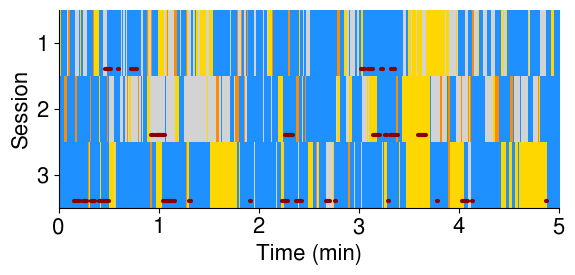

In [ ]:
plot_intvl = 1
session_start_idx = 1
session_end_idx = 4
num_sessions = session_end_idx - session_start_idx

plot_minutes_start = 0
plot_minutes_end = 5
plot_frames_start = int(fps * 60 * plot_minutes_start)
plot_frames_end = int(fps * 60 * plot_minutes_end)

fontsize = 16

observer_behaviors = []

for session_idx in np.arange(session_start_idx, session_end_idx):
    session_behavior = pred_d_s_mtx_smpl[session_idx, plot_frames_start:plot_frames_end]
    observer_behaviors.append(session_behavior)

observer_behaviors = np.stack(observer_behaviors)

fig, ax = plt.subplots(nrows = 1, figsize = (6, 3), sharex = True)

ax.imshow(observer_behaviors, aspect = "auto", cmap = cat_during_attk_cmap, 
          interpolation = "none")

# Add black horizontal lines to indicate attack periods for each session
for plot_idx, session_idx in enumerate(np.arange(session_start_idx, session_end_idx)):
    attack_periods = attack_labels_mtx[session_idx, plot_frames_start:plot_frames_end]
    attack_starts = np.where(np.diff(np.concatenate(([0], attack_periods))) == 1)[0]
    attack_ends = np.where(np.diff(np.concatenate((attack_periods, [0]))) == -1)[0]

    for start, end in zip(attack_starts, attack_ends):
        ax.plot([start, end], [plot_idx + 0.4, plot_idx + 0.4], 
                color='darkred', linewidth=3, alpha = 1, solid_capstyle='round')

ax.set_xticks(np.arange(0, plot_frames_end - plot_frames_start + 1, fps * 60 * plot_intvl), 
              np.arange(plot_minutes_start, plot_minutes_end + 1, plot_intvl), fontsize = fontsize)

ax.set_yticks(np.arange(num_sessions), [f"{i + 1}" for i in range(num_sessions)], fontsize = fontsize)

ax.set_xlabel("Time (min)", fontsize = fontsize)
ax.set_ylabel("Session", fontsize = fontsize)

plt.tight_layout()
sns.despine()

plt.savefig(os.path.join(pub_path, "analysis_figa.svg"), format = "svg")